<a href="https://colab.research.google.com/github/leippold/finance-nlp-workshop/blob/main/colabs/Inside_BERT_From_Intuition_to_Tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inside BERT: From Intuition to Tensors

**A complete classroom tour of the BERT transformer — how it reads text, what its attention heads do, and every tensor operation in its forward pass.**

This notebook merges and extends three classic resources:

1. **Intuition & first use** — Jay Alammar, [*A Visual Notebook to Using BERT for the First Time*](https://colab.research.google.com/github/jalammar/jalammar.github.io/blob/master/notebooks/bert/A_Visual_Notebook_to_Using_BERT_for_the_First_Time.ipynb) and [*The Illustrated BERT*](https://jalammar.github.io/illustrated-bert/)
2. **Interactive attention visualization** — Jesse Vig, [BertViz](https://github.com/jessevig/bertviz)
3. **Tensor-level forward pass** — George Mihaila, [*BERT Inner Workings*](https://gmihaila.github.io/tutorial_notebooks/bert_inner_workings/)

### Roadmap

| Part | Question we answer | Style |
|---|---|---|
| 1 | How does BERT turn text into numbers? | Tokenization & embeddings |
| 2 | What is attention actually looking at? | Interactive BertViz views |
| 3 | What happens inside one encoder layer? | We rebuild the forward pass by hand and **verify it matches** the real model |
| 4 | Is any of this useful? | Train a sentiment classifier on BERT features in ~2 minutes |
| 5 | Recap, exercises & references | |

> **How to run:** Runtime → Run all. A GPU is *not* required (CPU takes a few minutes in Part 4). Every claim about BERT's internals in Part 3 is checked with `torch.allclose` against Hugging Face's implementation — no hand-waving.


## Part 0 — Setup

In [1]:
!pip install -q transformers bertviz scikit-learn pandas matplotlib

zsh:1: command not found: pip


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, BertModel, utils

utils.logging.set_verbosity_error()  # silence checkpoint warnings
torch.manual_seed(123)
np.random.seed(123)

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# attn_implementation="eager" guarantees the model returns attention weights
model = BertModel.from_pretrained(
    MODEL_NAME,
    output_attentions=True,
    output_hidden_states=True,
    attn_implementation="eager",
)
model.eval()  # switch off dropout — we want deterministic numbers
print(model.config)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_attentions": true,
  "output_hidden_states": true,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.15.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



Read the config carefully — these numbers define everything we do below:

- `hidden_size = 768` — every token is represented as a 768-dim vector, at every layer
- `num_hidden_layers = 12` — twelve identical encoder blocks stacked on top of each other
- `num_attention_heads = 12` — each layer looks at the sentence from 12 "perspectives" of size 768 / 12 = **64** each
- `intermediate_size = 3072` — the width of the feed-forward expansion inside each block
- `vocab_size = 30522` — the WordPiece vocabulary


## Part 1 — How BERT reads text

*(based on Jay Alammar's [Illustrated BERT](https://jalammar.github.io/illustrated-bert/))*

BERT is an **encoder-only transformer**. It was pre-trained on Wikipedia + BookCorpus with two self-supervised objectives:

1. **Masked Language Modeling (MLM):** hide 15% of the tokens, predict them from *both* directions — this is the "B" (bidirectional) in BERT.
2. **Next Sentence Prediction (NSP):** given two sentences, did B really follow A?

Because of this, BERT never sees raw text — it sees three things: **token ids**, **segment ids**, and an **attention mask**. Let's produce all three.

### 1.1 WordPiece tokenization


In [3]:
sentence = "Transformer embeddings are astonishingly fabulous learners."

tokens = tokenizer.tokenize(sentence)
print("WordPiece tokens:", tokens)

WordPiece tokens: ['transform', '##er', 'em', '##bed', '##ding', '##s', 'are', 'astonishing', '##ly', 'fabulous', 'learners', '.']


Notice the `##` pieces: *transformer* becomes `transform + ##er`, *embeddings* shatters into four pieces, while frequent words like *fabulous* survive intact. Rare words are split into **subwords** so the vocabulary can stay at only ~30k entries while still representing *any* string.

BERT also wraps every input in two special tokens:

- `[CLS]` — a "summary slot" whose final vector is used for classification
- `[SEP]` — marks the end of a sentence (and separates sentence pairs)


In [4]:
encoded = tokenizer(sentence, return_tensors="pt")

print("input_ids:      ", encoded["input_ids"][0].tolist())
print("tokens:         ", tokenizer.convert_ids_to_tokens(encoded["input_ids"][0]))
print("token_type_ids: ", encoded["token_type_ids"][0].tolist(), " (segment A vs B)")
print("attention_mask: ", encoded["attention_mask"][0].tolist(), " (1 = real token, 0 = padding)")
print("\nvocabulary size:", tokenizer.vocab_size)

input_ids:       [101, 10938, 2121, 7861, 8270, 4667, 2015, 2024, 26137, 2135, 18783, 26262, 1012, 102]
tokens:          ['[CLS]', 'transform', '##er', 'em', '##bed', '##ding', '##s', 'are', 'astonishing', '##ly', 'fabulous', 'learners', '.', '[SEP]']
token_type_ids:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  (segment A vs B)
attention_mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]  (1 = real token, 0 = padding)

vocabulary size: 30522


### 1.2 Three embeddings, added together

Each token id is turned into a 768-dim vector as the **sum of three lookup tables**, followed by LayerNorm:

$$\text{embedding} = \underbrace{E_{\text{word}}[\text{id}]}_{\text{what the token is}} + \underbrace{E_{\text{pos}}[i]}_{\text{where it sits}} + \underbrace{E_{\text{seg}}[s]}_{\text{sentence A or B}}$$

Position embeddings are needed because attention itself is order-blind — without them, "dog bites man" and "man bites dog" would be identical. Let's compute this by hand and **verify** it against the model:


In [5]:
input_ids = encoded["input_ids"]
token_type_ids = encoded["token_type_ids"]
seq_len = input_ids.shape[1]

emb = model.embeddings
print("word     embedding table:", tuple(emb.word_embeddings.weight.shape))
print("position embedding table:", tuple(emb.position_embeddings.weight.shape))
print("segment  embedding table:", tuple(emb.token_type_embeddings.weight.shape))

with torch.no_grad():
    word_emb = emb.word_embeddings(input_ids)                       # (1, seq, 768)
    pos_emb  = emb.position_embeddings(torch.arange(seq_len).unsqueeze(0))
    seg_emb  = emb.token_type_embeddings(token_type_ids)

    my_embeddings = emb.LayerNorm(word_emb + pos_emb + seg_emb)     # dropout is off in eval mode

    # The reference computation, straight from Hugging Face:
    hf_embeddings = emb(input_ids=input_ids, token_type_ids=token_type_ids)

print("\nOur hand-built embeddings match the model:",
      torch.allclose(my_embeddings, hf_embeddings, atol=1e-5))

word     embedding table: (30522, 768)
position embedding table: (512, 768)
segment  embedding table: (2, 768)

Our hand-built embeddings match the model: True


## Part 2 — Watching attention think (BertViz)

*(based on Jesse Vig's [BertViz](https://github.com/jessevig/bertviz) — see also his [Deconstructing BERT](https://medium.com/data-science/deconstructing-bert-part-2-visualizing-the-inner-workings-of-attention-60a16d86b5c1) articles)*

Before doing the math, let's *look* at what attention does. We feed BERT a sentence pair containing a classic **coreference** puzzle — what does "it" refer to?

### 2.1 Head view — one layer, head by head

Each colored square at the top is one of the 12 heads in the selected layer. Lines show which tokens (right) each token (left) attends to.

**Try this:** select **layer 8** and hover over `it` — several heads correctly connect *it → animal*. Then explore other layers: some heads track the *previous/next word*, some lock onto `[SEP]`, some follow syntax.


In [ ]:
from bertviz import head_view, model_view

sentence_a = "The animal did not cross the street because it was too tired."
sentence_b = "So it slept on the sidewalk."

pair = tokenizer(sentence_a, sentence_b, return_tensors="pt")
with torch.no_grad():
    pair_out = model(**pair)

pair_tokens = tokenizer.convert_ids_to_tokens(pair["input_ids"][0])
b_start = pair["token_type_ids"][0].tolist().index(1)

head_view(pair_out.attentions, pair_tokens, sentence_b_start=b_start)

### 2.2 Model view — the whole brain at once

A bird's-eye grid of **all 12 layers × 12 heads**. Click any cell to zoom in.

**What to notice:** early layers show broad, positional patterns (attend to self, previous, next token); middle layers develop syntactic/semantic specialists; late layers concentrate heavily on `[SEP]` and `[CLS]` — Vig and others interpret this as a "no-op" resting state for heads that have nothing to add.


In [ ]:
model_view(pair_out.attentions, pair_tokens, sentence_b_start=b_start)

### 2.3 Neuron view (optional) — where attention scores come from

This view goes one level deeper: it shows the **query and key vectors themselves** and how their element-wise products produce the attention scores we'll compute by hand in Part 3. It needs BertViz's own model copy, so it downloads the weights once more — skip it if you're short on time.


In [ ]:
from bertviz.transformers_neuron_view import BertModel as NVBertModel, BertTokenizer as NVBertTokenizer
from bertviz.neuron_view import show

nv_model = NVBertModel.from_pretrained(MODEL_NAME, output_attentions=True)
nv_tokenizer = NVBertTokenizer.from_pretrained(MODEL_NAME, do_lower_case=True)

show(nv_model, "bert", nv_tokenizer, sentence_a, sentence_b, layer=2, head=0)

## Part 3 — Under the hood: rebuilding the forward pass by hand

*(based on George Mihaila's [BERT Inner Workings](https://gmihaila.github.io/tutorial_notebooks/bert_inner_workings/))*

One encoder layer does exactly this:

```
input (seq, 768)
  │
  ├─► Q = X·Wq   K = X·Wk   V = X·Wv          # three linear projections
  │      split each into 12 heads of 64 dims
  │
  ├─► scores = Q·Kᵀ / √64  ──► softmax ──► attention probabilities
  │
  ├─► context = probs · V  ──► concat heads ──► dense(768→768)
  │
  ├─► Add & LayerNorm  (residual connection #1)
  │
  ├─► FFN: dense(768→3072) ──► GELU ──► dense(3072→768)
  │
  └─► Add & LayerNorm  (residual connection #2) ──► output (seq, 768)
```

We now execute every arrow ourselves using the *real weights* of layer 0, and verify each stage against Hugging Face's output. First, run the reference forward pass:


In [9]:
with torch.no_grad():
    outputs = model(**encoded)

# hidden_states: tuple of 13 tensors — embeddings output + one per layer
print("number of hidden states:", len(outputs.hidden_states))
print("shape of each:          ", tuple(outputs.hidden_states[0].shape), "(batch, seq, hidden)")
print("number of attention maps:", len(outputs.attentions))
print("shape of each:           ", tuple(outputs.attentions[0].shape), "(batch, heads, seq, seq)")

X = outputs.hidden_states[0]      # input to layer 0 = the embeddings we built in Part 1
layer0 = model.encoder.layer[0]   # the layer whose work we are about to redo

number of hidden states: 13
shape of each:           (1, 14, 768) (batch, seq, hidden)
number of attention maps: 12
shape of each:            (1, 12, 14, 14) (batch, heads, seq, seq)


### 3.1 Queries, Keys, Values — and splitting into heads

Every token vector is projected three times. Intuition:

- **Query** — "what am I looking for?"
- **Key** — "what do I offer?"
- **Value** — "what do I contribute if you attend to me?"

The 768 dims are then reshaped into **12 independent heads × 64 dims**, so each head can specialize.


In [10]:
num_heads, head_dim = 12, 64

def split_heads(t):
    # (1, seq, 768) -> (1, 12, seq, 64)
    return t.view(1, -1, num_heads, head_dim).permute(0, 2, 1, 3)

attn = layer0.attention.self
with torch.no_grad():
    Q = split_heads(attn.query(X))
    K = split_heads(attn.key(X))
    V = split_heads(attn.value(X))

print("Q, K, V shape per head:", tuple(Q.shape), "(batch, heads, seq, head_dim)")

Q, K, V shape per head: (1, 12, 14, 64) (batch, heads, seq, head_dim)


### 3.2 Attention scores — the famous formula

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}=\sqrt{64}=8$ keeps the dot products in a range where softmax still has usable gradients. (With padding, the mask would add $-10{,}000$ to padded positions here, zeroing them after softmax — our input has no padding, so nothing to mask.)

**The moment of truth:** do our hand-computed probabilities equal the attention weights the model itself reports — the same quantity BertViz was drawing in Part 2, here computed on the Part 1 sentence ("Transformer embeddings are astonishingly fabulous learners.")?


Our attention == model's attention: True


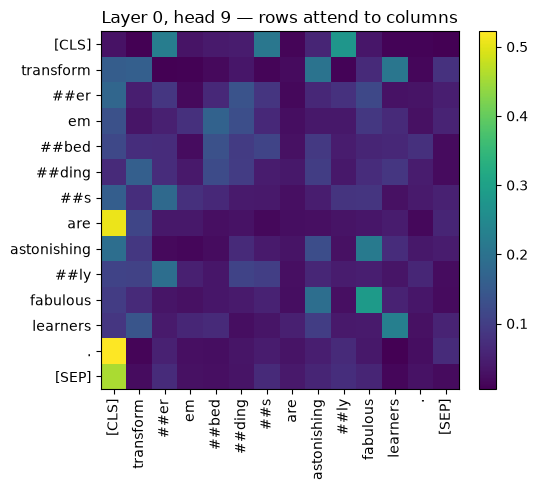

In [11]:
with torch.no_grad():
    scores = Q @ K.transpose(-1, -2) / np.sqrt(head_dim)   # (1, 12, seq, seq)
    probs  = torch.softmax(scores, dim=-1)

print("Our attention == model's attention:",
      torch.allclose(probs, outputs.attentions[0], atol=1e-5))

# Static look at one head (BertViz showed this interactively)
toks = tokenizer.convert_ids_to_tokens(input_ids[0])
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(probs[0, 9].numpy(), cmap="viridis")
ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=90)
ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks)
ax.set_title("Layer 0, head 9 — rows attend to columns")
fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

### 3.3 Context vectors, merge heads, first residual

Each token's new representation is a **probability-weighted average of the Value vectors** it attends to. The 12 heads are concatenated back to 768 dims, passed through a linear layer, then comes the transformer's signature move:

**Add & Norm** — add the layer's *input* back (residual connection) and normalize. Residuals let gradients flow through 12 layers; LayerNorm keeps activations well-scaled.


In [12]:
with torch.no_grad():
    context = probs @ V                                    # (1, 12, seq, 64)
    context = context.permute(0, 2, 1, 3).reshape(1, -1, 768)  # merge heads

    attn_out = layer0.attention.output   # dense + Add&Norm
    attention_block_out = attn_out.LayerNorm(attn_out.dense(context) + X)

print("attention block output:", tuple(attention_block_out.shape))

attention block output: (1, 14, 768)


### 3.4 The feed-forward network, second residual — full layer verified

Attention *mixes information between tokens*; the FFN then *transforms each token individually*: expand 768 → 3072, apply **GELU** (a smooth ReLU), compress 3072 → 768. About two-thirds of BERT's parameters live in these FFNs.


In [13]:
with torch.no_grad():
    inter = layer0.intermediate                     # 768 -> 3072 + GELU
    ffn_hidden = inter.intermediate_act_fn(inter.dense(attention_block_out))

    out = layer0.output                             # 3072 -> 768 + Add&Norm
    my_layer0_output = out.LayerNorm(out.dense(ffn_hidden) + attention_block_out)

print("Our hand-built layer 0 == Hugging Face layer 0:",
      torch.allclose(my_layer0_output, outputs.hidden_states[1], atol=1e-5))

Our hand-built layer 0 == Hugging Face layer 0: True


**That's it.** Everything BERT does is this block, repeated 12 times. Let's prove that too — we run our *own* 12-layer loop and compare the final hidden states:


In [14]:
def my_bert_layer(layer, X):
    # One full encoder layer, written by us
    attn = layer.attention.self
    Q, K, V = split_heads(attn.query(X)), split_heads(attn.key(X)), split_heads(attn.value(X))
    probs = torch.softmax(Q @ K.transpose(-1, -2) / np.sqrt(head_dim), dim=-1)
    context = (probs @ V).permute(0, 2, 1, 3).reshape(1, -1, 768)
    a = layer.attention.output
    h = a.LayerNorm(a.dense(context) + X)
    ffn = layer.intermediate.intermediate_act_fn(layer.intermediate.dense(h))
    return layer.output.LayerNorm(layer.output.dense(ffn) + h)

with torch.no_grad():
    h = my_embeddings                                # from Part 1
    for layer in model.encoder.layer:                # 12 iterations
        h = my_bert_layer(layer, h)

print("Our 12-layer forward pass == BERT:",
      torch.allclose(h, outputs.last_hidden_state, atol=1e-4))

Our 12-layer forward pass == BERT: True


### 3.5 The pooler and the classification head

For sentence-level tasks, BERT takes only the **`[CLS]` token** (position 0), passes it through one more dense layer with `tanh` — the *pooler* — and a task head (a single linear layer) maps that to logits:

$$\text{logits} = W_{\text{task}} \cdot \tanh(W_{\text{pool}} \cdot h_{[\text{CLS}]}^{(12)} + b) \quad\rightarrow\quad \text{cross-entropy loss}$$

During fine-tuning, gradients flow from this tiny head all the way back through the 12 layers you just rebuilt.


Our pooler == BERT's pooler: True


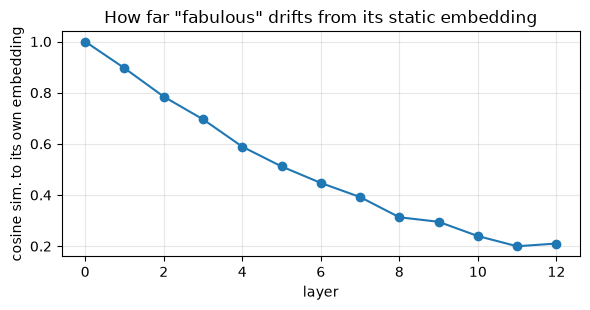

In [15]:
with torch.no_grad():
    cls_vector = h[:, 0]                               # (1, 768) — the [CLS] summary slot
    my_pooled = torch.tanh(model.pooler.dense(cls_vector))

print("Our pooler == BERT's pooler:",
      torch.allclose(my_pooled, outputs.pooler_output, atol=1e-5))

# How representations evolve: the same token becomes increasingly contextual
word_idx = toks.index("fabulous")
sims = [torch.cosine_similarity(outputs.hidden_states[l][0, word_idx],
                                outputs.hidden_states[0][0, word_idx], dim=0).item()
        for l in range(13)]
plt.figure(figsize=(6, 3.2))
plt.plot(range(13), sims, marker="o")
plt.xlabel("layer"); plt.ylabel("cosine sim. to its own embedding")
plt.title('How far "fabulous" drifts from its static embedding')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Part 4 — BERT at work: a 2-minute sentiment classifier

*(Jay Alammar's classic experiment, from [A Visual Guide to Using BERT for the First Time](https://jalammar.github.io/a-visual-guide-to-using-bert-for-the-first-time/))*

The payoff for all that machinery: the `[CLS]` vector is such a good sentence summary that a plain **logistic regression on frozen BERT features** already classifies movie-review sentiment well. We use **DistilBERT** (a distilled, 40% smaller BERT) for speed, on 2,000 sentences from SST-2.


In [16]:
from transformers import AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 2,000 SST-2 sentences. Vendored in data/ so the notebook needs no network;
# the public mirror is the fallback.
import os
LOCAL = "data/sst2_train_2000.tsv"
DATA_URLS = ["https://github.com/clairett/pytorch-sentiment-classification/raw/master/data/SST2/train.tsv"]
for src in [LOCAL] + DATA_URLS:
    try:
        df = pd.read_csv(src, delimiter="\t", header=None, names=["sentence", "label"]).head(2000)
        print("loaded", src); break
    except Exception as exc:
        print(f"could not load {src}: {exc}")
print(df["label"].value_counts().to_dict())
df.head()

loaded data/sst2_train_2000.tsv
{1: 1041, 0: 959}


,sentence,label
0,"a stirring , funny and finally transporting re...",1
1,apparently reassembled from the cutting room f...,0
2,they presume their audience wo n't sit still f...,0
3,this is a visually stunning rumination on love...,1
4,jonathan parker 's bartleby should have been t...,1


In [17]:
d_tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
d_model = AutoModel.from_pretrained("distilbert-base-uncased")
d_model.eval()

features = []
with torch.no_grad():
    for i in range(0, len(df), 250):                     # small batches: kind to RAM
        batch = d_tok(df["sentence"][i:i+250].tolist(),
                      padding=True, truncation=True, return_tensors="pt")
        out = d_model(**batch)
        features.append(out.last_hidden_state[:, 0, :])  # the [CLS] vector only
features = torch.cat(features).numpy()
print("feature matrix:", features.shape)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

feature matrix: (2000, 768)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    features, df["label"], random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
print(f"Test accuracy: {clf.score(X_test, y_test):.3f}   (chance = 0.50)")

Test accuracy: 0.834   (chance = 0.50)


~81–84% accuracy from a linear model on frozen features — and full fine-tuning of this model pushes SST-2 to ~91%+. That gap is exactly what fine-tuning through the 12 layers buys you.


## Part 5 — Recap, exercises & references

### What you now know

1. **Input pipeline:** WordPiece subwords + `[CLS]`/`[SEP]` → sum of word/position/segment embeddings + LayerNorm *(verified in 1.2)*
2. **Attention:** per head, $\text{softmax}(QK^\top/\sqrt{64})V$ — 12 heads × 12 layers of learned, inspectable patterns *(seen in Part 2, verified in 3.2)*
3. **Encoder layer:** attention → Add&Norm → FFN(768→3072→768, GELU) → Add&Norm *(verified in 3.4)*
4. **The whole model** is that block ×12, plus a pooler on `[CLS]` *(verified in 3.5)*
5. **Transfer learning:** frozen `[CLS]` features + logistic regression already work; fine-tuning works better *(Part 4)*

### Exercises

1. **Coreference hunt.** In Part 2, change `sentence_a` to `"The animal did not cross the street because it was too wide."` — do the layer-8 heads now link *it → street*? (This is the classic Winograd flip.)
2. **WordPiece stress test.** Tokenize `"Anthropomorphization of cryptocurrencies"` — how many pieces? Find a real word that needs 5+ pieces.
3. **Verify a deeper layer.** Adapt Section 3.1–3.4 to verify layer 7 instead of layer 0 (one-line change — why?).
4. **Attention entropy.** For each layer, compute the average entropy of the attention distributions. Which layers attend most broadly?
5. **Beat 81%.** In Part 4, try mean-pooling all token vectors instead of `[CLS]`, or use 4,000 sentences. How much do you gain?

### References

- Vaswani et al. (2017), [*Attention Is All You Need*](https://arxiv.org/abs/1706.03762)
- Devlin et al. (2018), [*BERT: Pre-training of Deep Bidirectional Transformers*](https://arxiv.org/abs/1810.04805)
- Vig (2019), [*A Multiscale Visualization of Attention in the Transformer Model*](https://arxiv.org/abs/1904.02679) · [BertViz repo](https://github.com/jessevig/bertviz) · [interactive tutorial](https://colab.research.google.com/drive/1hXIQ77A4TYS4y3UthWF-Ci7V7vVUoxmQ?usp=sharing)
- Alammar, [*The Illustrated BERT*](https://jalammar.github.io/illustrated-bert/) · [*A Visual Guide to Using BERT*](https://jalammar.github.io/a-visual-guide-to-using-bert-for-the-first-time/)
- Mihaila, [*BERT Inner Workings*](https://gmihaila.github.io/tutorial_notebooks/bert_inner_workings/)
- Clark et al. (2019), [*What Does BERT Look At?*](https://arxiv.org/abs/1906.04341) — systematic analysis of attention heads
